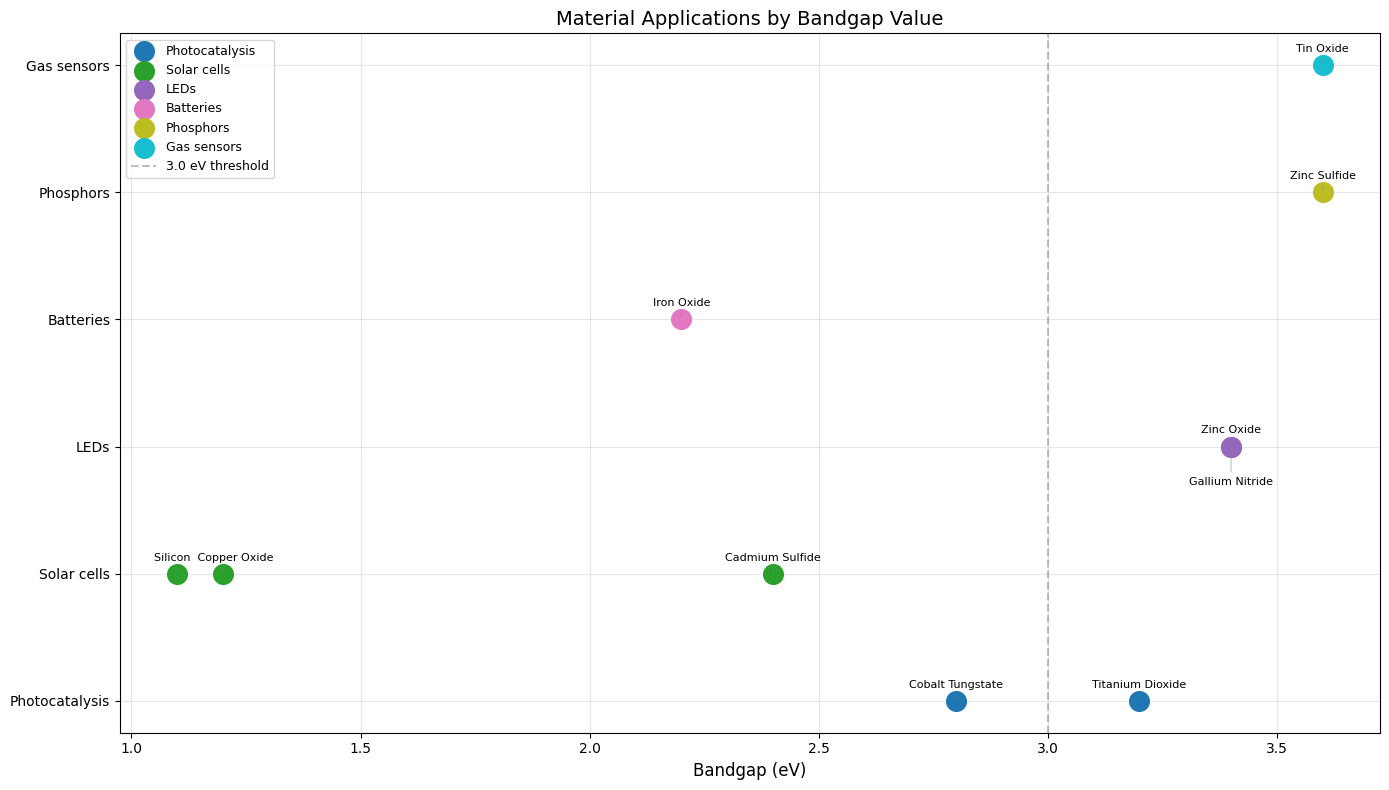

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

data = {
    "Material": [
        "Cobalt Tungstate", "Silicon   ", "Titanium Dioxide",
        "Zinc Oxide", "Gallium Nitride", "       Copper Oxide",
        "Iron Oxide", "Cadmium Sulfide", "Zinc Sulfide", "Tin Oxide"
    ],
    "Bandgap_eV": [2.8, 1.1, 3.2, 3.4, 3.4, 1.2, 2.2, 2.4, 3.6, 3.6],
    "Application": [
        "Photocatalysis", "Solar cells", "Photocatalysis",
        "LEDs", "LEDs", "Solar cells",
        "Batteries", "Solar cells", "Phosphors", "Gas sensors"
    ]
}

df = pd.DataFrame(data)
applications = df["Application"].unique()
colors = cm.tab10(np.linspace(0, 1, len(applications)))

plt.figure(figsize=(14, 8))

# Track positions to alternate above/below
position_count = {}

for i, app in enumerate(applications):
    subset = df[df["Application"] == app]
    plt.scatter(subset["Bandgap_eV"], [app]*len(subset),
                color=colors[i], s=200, label=app, zorder=3)

    for _, row in subset.iterrows():
        key = (round(row["Bandgap_eV"], 1), app)
        count = position_count.get(key, 0)
        position_count[key] = count + 1

        # First label goes ABOVE, second goes BELOW
        y_offset = 8 if count == 0 else -22
        va = 'bottom' if count == 0 else 'top'

        plt.annotate(row["Material"],
                    (row["Bandgap_eV"], app),
                    textcoords="offset points",
                    xytext=(0, y_offset),
                    ha='center',
                    va=va,
                    fontsize=8,
                    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.4))

plt.xlabel("Bandgap (eV)", fontsize=12)
plt.title("Material Applications by Bandgap Value", fontsize=14)
plt.axvline(x=3.0, color='gray', linestyle='--', alpha=0.5, label="3.0 eV threshold")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bandgap_vs_application.png", dpi=150)
plt.show()

from google.colab import files
files.download("bandgap_vs_application.png")